In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Query dataset

In [2]:
data = pd.read_csv("Cleaned_Viral_Social_Media_Trends.csv")
data

,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,1/13/22,TikTok,#Challenge,Short form video,UK,4163464,339431,53135,19346,High
1,Post_2,5/13/22,Instagram,#Education,Short form video,India,4155940,215240,65860,27239,Medium
2,Post_3,1/7/22,Twitter,#Challenge,Long form video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,12/5/22,YouTube,#Education,Short form video,Australia,917951,127125,11687,36806,Low
4,Post_5,3/23/23,TikTok,#Dance,Image post,Brazil,64866,171361,69581,6376,Medium
...,...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,5/5/23,YouTube,#Education,Long form video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,9/7/23,Instagram,#Education,Long form video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,6/12/22,YouTube,#Fashion,Short form video,USA,2004080,32401,75229,33875,Low
4998,Post_4999,5/23/23,Instagram,#Gaming,Short form video,Canada,2221665,46996,12954,42832,Low


### Performing Data Cleaning

#### Extracting Categorical dataset

In [3]:
CAT = data.select_dtypes('object')
CAT.head()

,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Engagement_Level
0,Post_1,1/13/22,TikTok,#Challenge,Short form video,UK,High
1,Post_2,5/13/22,Instagram,#Education,Short form video,India,Medium
2,Post_3,1/7/22,Twitter,#Challenge,Long form video,Brazil,Medium
3,Post_4,12/5/22,YouTube,#Education,Short form video,Australia,Low
4,Post_5,3/23/23,TikTok,#Dance,Image post,Brazil,Medium


#### Checking for inconsistencies

In [4]:
CAT['Platform'].value_counts()

Platform
YouTube      1324
TikTok       1260
Instagram    1212
Twitter      1204
Name: count, dtype: int64

In [5]:
CAT['Hashtag'].value_counts()

Hashtag
#Fitness      536
#Education    525
#Challenge    507
#Comedy       505
#Dance        496
#Music        493
#Tech         491
#Fashion      487
#Viral        481
#Gaming       479
Name: count, dtype: int64

In [6]:
CAT['Content_Type'].value_counts()

Content_Type
Short form video    1842
Live Stream          855
Image post           853
Text post            836
Long form video      614
Name: count, dtype: int64

In [7]:
CAT['Region'].value_counts()

Region
USA          677
Canada       658
UK           647
Brazil       641
India        617
Australia    602
Japan        592
Germany      566
Name: count, dtype: int64

In [8]:
CAT['Engagement_Level'].value_counts()

Engagement_Level
Low       1729
High      1673
Medium    1598
Name: count, dtype: int64

#### Checking for missing data

In [9]:
CAT.isna().sum()

Post_ID             0
Post_Date           0
Platform            0
Hashtag             0
Content_Type        0
Region              0
Engagement_Level    0
dtype: int64

In [10]:
# There are no misisng value

#### Checking for duplicates

In [11]:
CAT.duplicated().any()

np.False_

In [12]:
# No duplicates

#### Checking unnecessary data

In [13]:
CAT['Post_Date'] = pd.to_datetime(CAT['Post_Date'])

/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/3790966598.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  CAT['Post_Date'] = pd.to_datetime(CAT['Post_Date'])


In [14]:
CAT['Post_Date']

0      2022-01-13
1      2022-05-13
2      2022-01-07
3      2022-12-05
4      2023-03-23
          ...    
4995   2023-05-05
4996   2023-09-07
4997   2022-06-12
4998   2023-05-23
4999   2022-12-21
Name: Post_Date, Length: 5000, dtype: datetime64[ns]

In [15]:
CAT['Month'] = CAT['Post_Date'].dt.month
CAT['Month']

0        1
1        5
2        1
3       12
4        3
        ..
4995     5
4996     9
4997     6
4998     5
4999    12
Name: Month, Length: 5000, dtype: int32

In [16]:
# Converting months number to words

CAT['Month'].replace(1, 'JAN', inplace = True)
CAT['Month'].replace(2, 'FEB', inplace = True)
CAT['Month'].replace(3, 'MAR', inplace = True)
CAT['Month'].replace(4, 'APR', inplace = True)
CAT['Month'].replace(5, 'MAY', inplace = True)
CAT['Month'].replace(6, 'JUN', inplace = True)
CAT['Month'].replace(7, 'JUL', inplace = True)
CAT['Month'].replace(8, 'AUG', inplace = True)
CAT['Month'].replace(9, 'SEP', inplace = True)
CAT['Month'].replace(10, 'OCT', inplace = True)
CAT['Month'].replace(11, 'NOV', inplace = True)
CAT['Month'].replace(12, 'DEC', inplace = True)

In [17]:
CAT['Year'] = CAT['Post_Date'].dt.year
CAT['Year']

0       2022
1       2022
2       2022
3       2022
4       2023
        ... 
4995    2023
4996    2023
4997    2022
4998    2023
4999    2022
Name: Year, Length: 5000, dtype: int32

In [18]:
CAT

,Post_ID,Post_Date,Platform,Hashtag,Content_Type,Region,Engagement_Level,Month,Year
0,Post_1,2022-01-13,TikTok,#Challenge,Short form video,UK,High,JAN,2022
1,Post_2,2022-05-13,Instagram,#Education,Short form video,India,Medium,MAY,2022
2,Post_3,2022-01-07,Twitter,#Challenge,Long form video,Brazil,Medium,JAN,2022
3,Post_4,2022-12-05,YouTube,#Education,Short form video,Australia,Low,DEC,2022
4,Post_5,2023-03-23,TikTok,#Dance,Image post,Brazil,Medium,MAR,2023
...,...,...,...,...,...,...,...,...,...
4995,Post_4996,2023-05-05,YouTube,#Education,Long form video,Japan,High,MAY,2023
4996,Post_4997,2023-09-07,Instagram,#Education,Long form video,UK,Medium,SEP,2023
4997,Post_4998,2022-06-12,YouTube,#Fashion,Short form video,USA,Low,JUN,2022
4998,Post_4999,2023-05-23,Instagram,#Gaming,Short form video,Canada,Low,MAY,2023


#### Extracting numeric dataset

In [19]:
NUM = data.select_dtypes('number')
NUM

,Views,Likes,Shares,Comments
0,4163464,339431,53135,19346
1,4155940,215240,65860,27239
2,3666211,327143,39423,36223
3,917951,127125,11687,36806
4,64866,171361,69581,6376
...,...,...,...,...
4995,4258236,381509,59209,4674
4996,4841525,166266,54841,4832
4997,2004080,32401,75229,33875
4998,2221665,46996,12954,42832


#### Check for duplicates

In [20]:
NUM.duplicated().any()

np.False_

In [21]:
# There are no duplicates

#### Check for missing data

In [22]:
NUM.isna().any()

Views       False
Likes       False
Shares      False
Comments    False
dtype: bool

In [23]:
# There no missing values

In [24]:
NUM['Year'] = pd.to_numeric(CAT['Year'], errors = 'coerce')

In [25]:
# dropped Post_Date because I extracted the month and year 

In [26]:
CAT.drop(columns = ['Post_Date', 'Post_ID', 'Year', 'Engagement_Level'], axis = 1, inplace = True)

### Concatenating both categorical and numerical dataset

In [27]:
CONCAT = pd.concat([CAT, NUM], axis = 1)
CONCAT

,Platform,Hashtag,Content_Type,Region,Month,Views,Likes,Shares,Comments,Year
0,TikTok,#Challenge,Short form video,UK,JAN,4163464,339431,53135,19346,2022
1,Instagram,#Education,Short form video,India,MAY,4155940,215240,65860,27239,2022
2,Twitter,#Challenge,Long form video,Brazil,JAN,3666211,327143,39423,36223,2022
3,YouTube,#Education,Short form video,Australia,DEC,917951,127125,11687,36806,2022
4,TikTok,#Dance,Image post,Brazil,MAR,64866,171361,69581,6376,2023
...,...,...,...,...,...,...,...,...,...,...
4995,YouTube,#Education,Long form video,Japan,MAY,4258236,381509,59209,4674,2023
4996,Instagram,#Education,Long form video,UK,SEP,4841525,166266,54841,4832,2023
4997,YouTube,#Fashion,Short form video,USA,JUN,2004080,32401,75229,33875,2022
4998,Instagram,#Gaming,Short form video,Canada,MAY,2221665,46996,12954,42832,2023


In [28]:
col2 = CONCAT.pop('Month')   # removes the column and returns it
CONCAT.insert(1, 'Month', col2)

col2 = CONCAT.pop('Year')   # removes the column and returns it
CONCAT.insert(2, 'Year', col2)

### Exploratory Data Analysis

In [29]:
CAT.describe()

,Platform,Hashtag,Content_Type,Region,Month
count,5000,5000,5000,5000,5000
unique,4,10,5,8,12
top,YouTube,#Fitness,Short form video,USA,MAY
freq,1324,536,1842,677,445


In [30]:
pd.set_option('display.float_format', '{:.0f}'.format)

NUM.describe()

,Views,Likes,Shares,Comments,Year
count,5000,5000,5000,5000,5000
mean,2494066,251475,50520,24888,2022
std,1459490,144350,29066,14285,1
min,1266,490,52,18,2022
25%,1186207,126892,25029,12305,2022
50%,2497373,249443,50840,25004,2022
75%,3759781,373971,75774,37073,2023
max,4999430,499922,99978,49993,2023


In [31]:
CONCAT['Engagement'] = (
    CONCAT['Likes'] +
    CONCAT['Comments'] +
    CONCAT['Shares']
)

CONCAT['Engagement_Rate'] = (
    CONCAT['Engagement'] / CONCAT['Views']
) * 100


In [32]:
CONCAT

,Platform,Month,Year,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement,Engagement_Rate
0,TikTok,JAN,2022,#Challenge,Short form video,UK,4163464,339431,53135,19346,411912,10
1,Instagram,MAY,2022,#Education,Short form video,India,4155940,215240,65860,27239,308339,7
2,Twitter,JAN,2022,#Challenge,Long form video,Brazil,3666211,327143,39423,36223,402789,11
3,YouTube,DEC,2022,#Education,Short form video,Australia,917951,127125,11687,36806,175618,19
4,TikTok,MAR,2023,#Dance,Image post,Brazil,64866,171361,69581,6376,247318,381
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,YouTube,MAY,2023,#Education,Long form video,Japan,4258236,381509,59209,4674,445392,10
4996,Instagram,SEP,2023,#Education,Long form video,UK,4841525,166266,54841,4832,225939,5
4997,YouTube,JUN,2022,#Fashion,Short form video,USA,2004080,32401,75229,33875,141505,7
4998,Instagram,MAY,2023,#Gaming,Short form video,Canada,2221665,46996,12954,42832,102782,5


In [33]:
ENG_rate_by_type = (
    CONCAT.groupby('Content_Type')['Engagement_Rate']
    .mean()
    .sort_values(ascending=False)
)
ENG_rate_by_type

Content_Type
Short form video   64
Live Stream        62
Text post          52
Image post         50
Long form video    43
Name: Engagement_Rate, dtype: float64

#### Correlation Heatmap

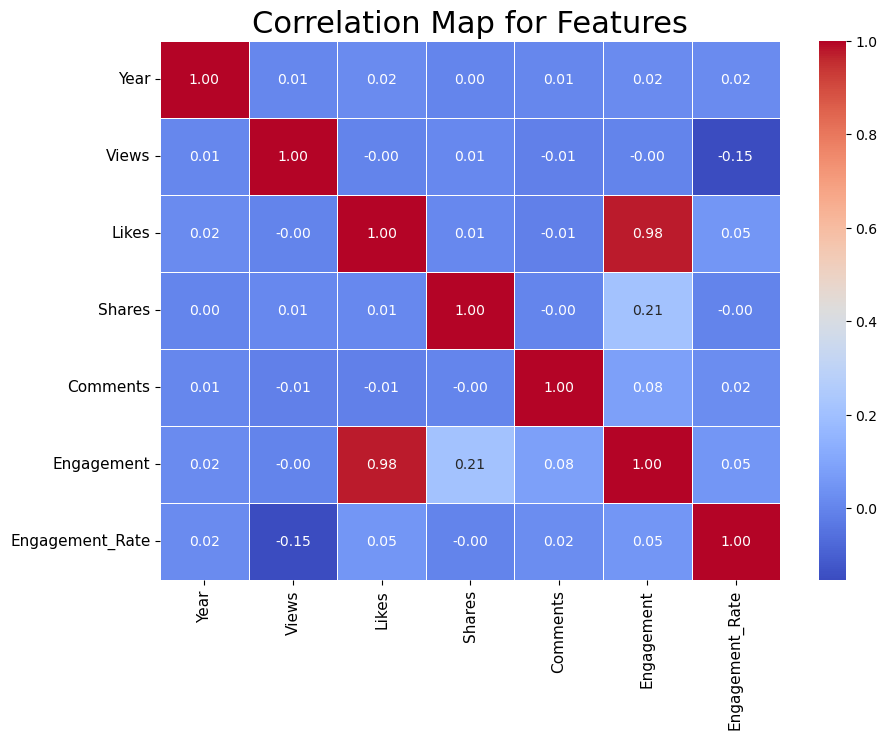

In [34]:
plt.figure(figsize=(10, 7))

# Compute correlation matrix
correlation_matrix = CONCAT.select_dtypes('number').corr()
# corr_d = correlation_matrix.drop('Engagement_Rate', axis = 1)

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Map for Features', fontsize = 22)
plt.tick_params(labelsize=11)

# Show plot
plt.show()

The correlation matrix indictaes that the number of likes is positively and highly correlated  with how an individual engages on any platform.

### Research Question 1

/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/3884421205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


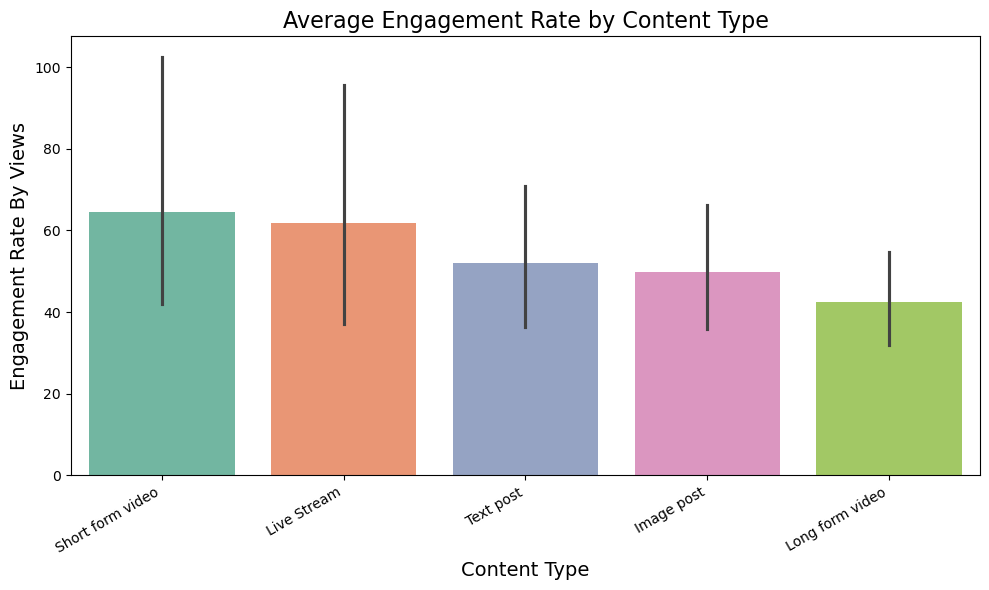

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=CONCAT,
    x='Content_Type',
    y='Engagement_Rate',
    estimator='mean',
    order=ENG_rate_by_type.index,
    palette='Set2'      # ← gives each bar a different color
)

plt.title('Average Engagement Rate by Content Type', fontsize=16)
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Engagement Rate By Views', fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


#### The plot above shows that short form videos keep individuals highly engaged across all platforms while long form videos indicate the lowest level of engagement.

### Research Question 2

In [36]:
ER_by_hashtag = (
    CONCAT.groupby('Hashtag')['Engagement_Rate']
          .mean()
          .sort_values(ascending=False)
)
ER_by_hashtag

Hashtag
#Viral       100
#Comedy       67
#Gaming       62
#Fitness      54
#Tech         54
#Education    51
#Fashion      49
#Dance        47
#Challenge    46
#Music        40
Name: Engagement_Rate, dtype: float64

/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/3717892430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


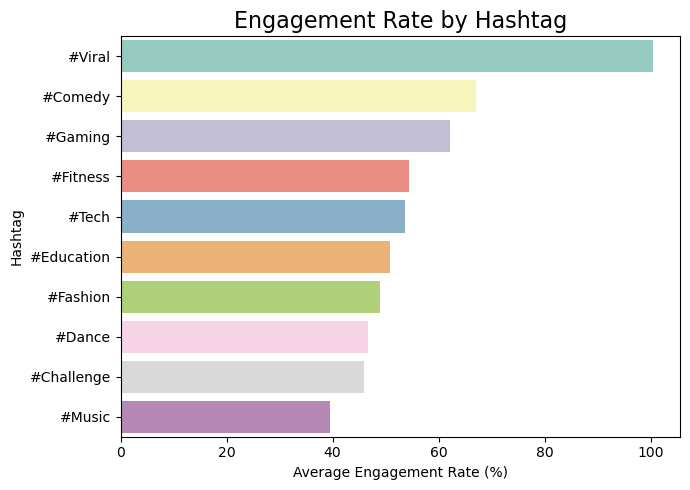

In [37]:
plt.figure(figsize=(7,5))
sns.barplot(
    x=ER_by_hashtag.values,
    y=ER_by_hashtag.index,
    palette='Set3'
)

plt.title('Engagement Rate by Hashtag', fontsize=16)
plt.xlabel('Average Engagement Rate (%)')
plt.ylabel('Hashtag')
plt.tight_layout()
plt.show()


#### Media posts that are tagged "#Viral" attracts individuals to be engaged across all platforms while "#Music" indicates otherwise

### Research Question 3

In [38]:
platform_data = (
    CONCAT
    .groupby(['Region', 'Content_Type', 'Platform'])['Engagement_Rate']
    .mean()
    .reset_index()
)

platform_data


,Region,Content_Type,Platform,Engagement_Rate
0,Australia,Image post,Instagram,18
1,Australia,Image post,TikTok,88
2,Australia,Image post,Twitter,21
3,Australia,Image post,YouTube,67
4,Australia,Live Stream,Instagram,108
...,...,...,...,...
147,USA,Short form video,YouTube,66
148,USA,Text post,Instagram,29
149,USA,Text post,TikTok,51
150,USA,Text post,Twitter,24


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/1233720861.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


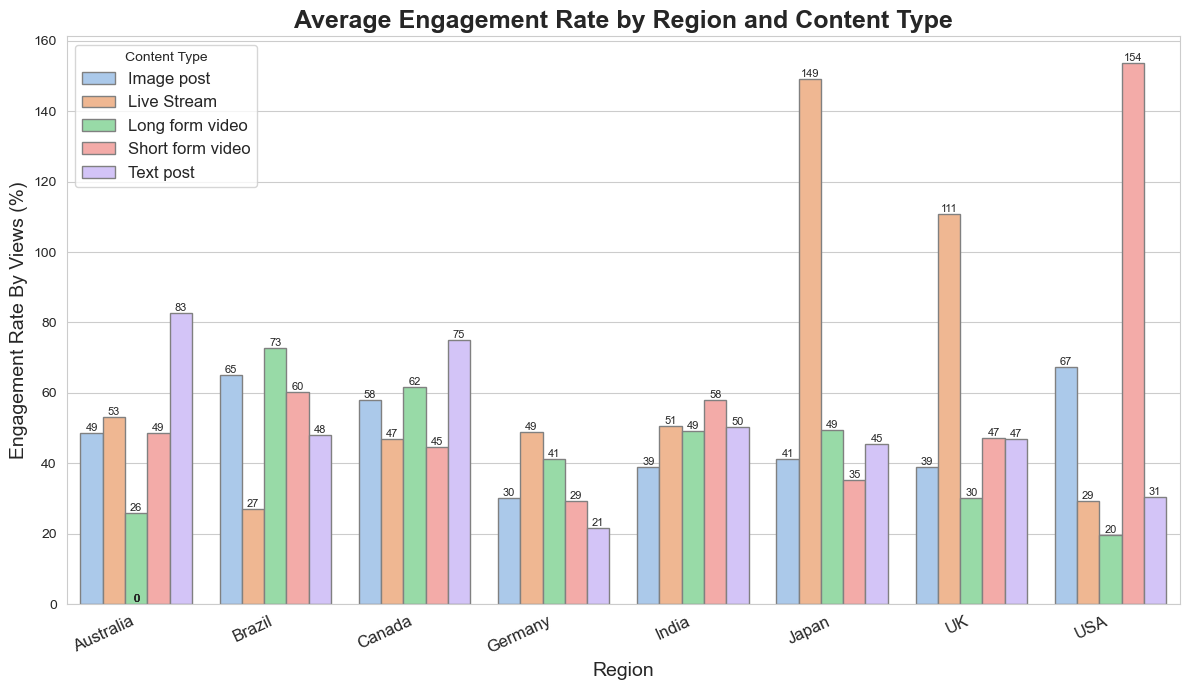

In [39]:
sns.set_style("whitegrid")
sns.set_palette("pastel")

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=platform_data,
    x='Region',
    y='Engagement_Rate',
    hue='Content_Type',
    edgecolor='grey',
    ci=None              # <-- removes the black error bars
)

plt.title('Average Engagement Rate by Region and Content Type',
          fontsize=18, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Engagement Rate By Views (%)', fontsize=14)
plt.xticks(rotation=25, ha='right', fontsize=12)
plt.legend(title='Content Type', fontsize=12)

# Add labels on bars
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.0f}',
                (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### Individuals from Japan prefer engage more on all platforms by having live streams, followed individuals in UK.

#### Individuals from USA prefer engage more on all platforms with short videos with long videos being the worst to be engaged.

#### Individuals from Australia prefer engage more on all platforms with text post, followed individuals in Canada.

### Research Question 4

In [40]:
region_platform_eng = (
    CONCAT
    .groupby(['Region', 'Platform'], observed=True)['Engagement_Rate']
    .mean()
    .reset_index()
)

print(region_platform_eng.head())


      Region   Platform  Engagement_Rate
0  Australia  Instagram               89
1  Australia     TikTok               57
2  Australia    Twitter               27
3  Australia    YouTube               47
4     Brazil  Instagram               87


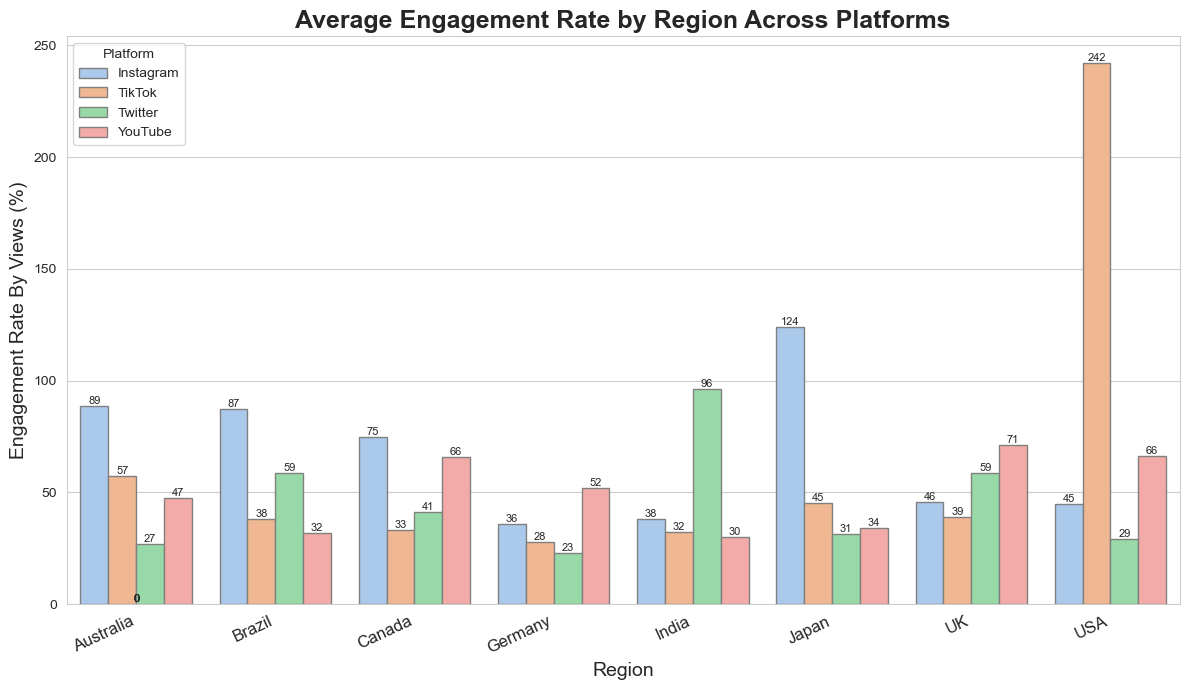

In [41]:
sns.set_style("whitegrid")
sns.set_palette("pastel")

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=region_platform_eng,
    x='Region',
    y='Engagement_Rate',
    hue='Platform',
    edgecolor='grey',
    linewidth=1
)

plt.title('Average Engagement Rate by Region Across Platforms',
          fontsize=18, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Engagement Rate By Views (%)', fontsize=14)
plt.xticks(rotation=25, ha='right', fontsize=12)
plt.legend(title='Platform', fontsize=10)

# Optional: add value labels on bars
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.0f}',
                (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


#### In USA, individuals prefer TikTok and less of Twitter.

#### With Japan leading the chart, followed by Australia, Brazil and Canada prefer TikTok as their engagement plaform.

#### In UK, individuals prefer more of YouTube and less of Tiktok.

#### In India, individuals prefer more of Twitter and less of YouTube.

### Other Findings

In [42]:
platform_data = (
    CONCAT.groupby(['Region', 'Content_Type', 'Platform'])['Engagement_Rate'] .mean() .reset_index()
)
platform_data

,Region,Content_Type,Platform,Engagement_Rate
0,Australia,Image post,Instagram,18
1,Australia,Image post,TikTok,88
2,Australia,Image post,Twitter,21
3,Australia,Image post,YouTube,67
4,Australia,Live Stream,Instagram,108
...,...,...,...,...
147,USA,Short form video,YouTube,66
148,USA,Text post,Instagram,29
149,USA,Text post,TikTok,51
150,USA,Text post,Twitter,24


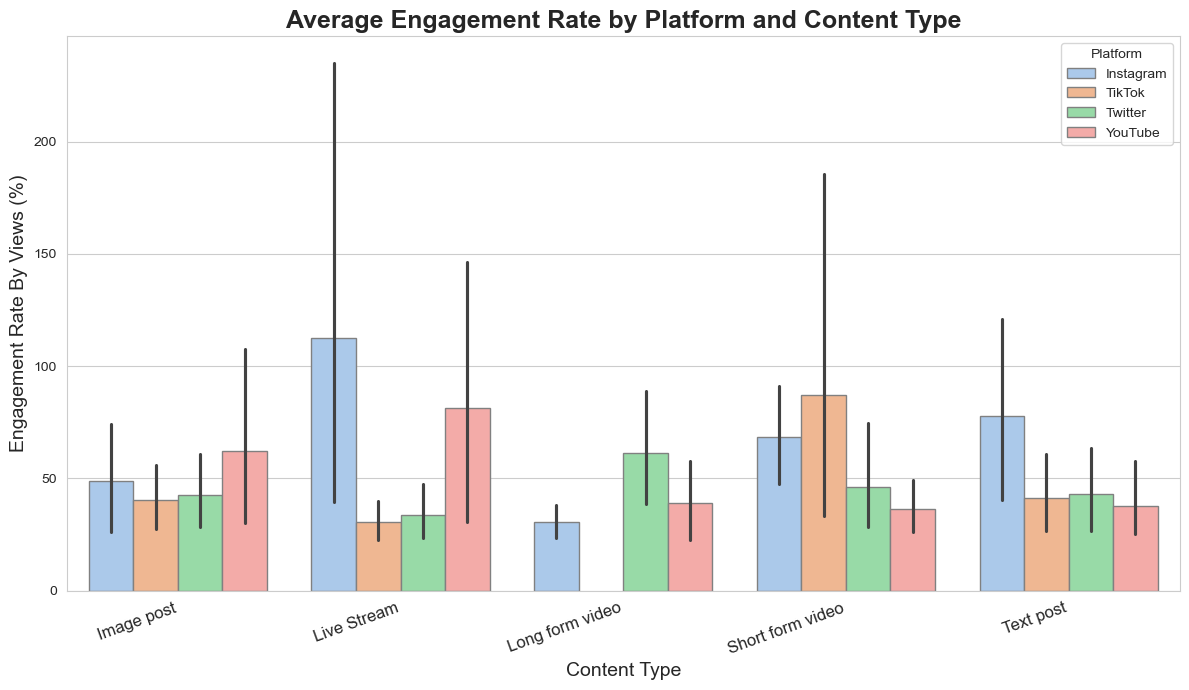

In [43]:
# Aesthetic setup
sns.set_style("whitegrid")
sns.set_palette("pastel")

plt.figure(figsize=(12,7))

sns.barplot(
    data=platform_data,
    x='Content_Type',
    y='Engagement_Rate',
    hue='Platform',
    edgecolor='grey',
    linewidth=1
)

# Title & labels
plt.title('Average Engagement Rate by Platform and Content Type',
          fontsize=18, fontweight='bold')
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Engagement Rate By Views (%)', fontsize=14)
plt.xticks(rotation=20, ha='right', fontsize=12)
plt.legend(title='Platform', fontsize=10)

plt.tight_layout()
plt.show()


#### Twitter tops the chat for short form video content, while Youtube indicates lowest engagement for such content type.

#### For Long form videos, Twitter takes off with engagement while Tiktok shows the lowest engagement for long video post.

#### Post like images give rise to Youtube viewers compared to all platforms, Tiktok having the lowest engagement for image post.

#### Individuals tend to interact more on Instagram for text posts, while YouTube falling short for text posts.

#### Live Streams affect engagement levels across platforms indicating Instagram with the highest rate while Tiktok less interactive for use.

#### Plot

/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/3210834978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


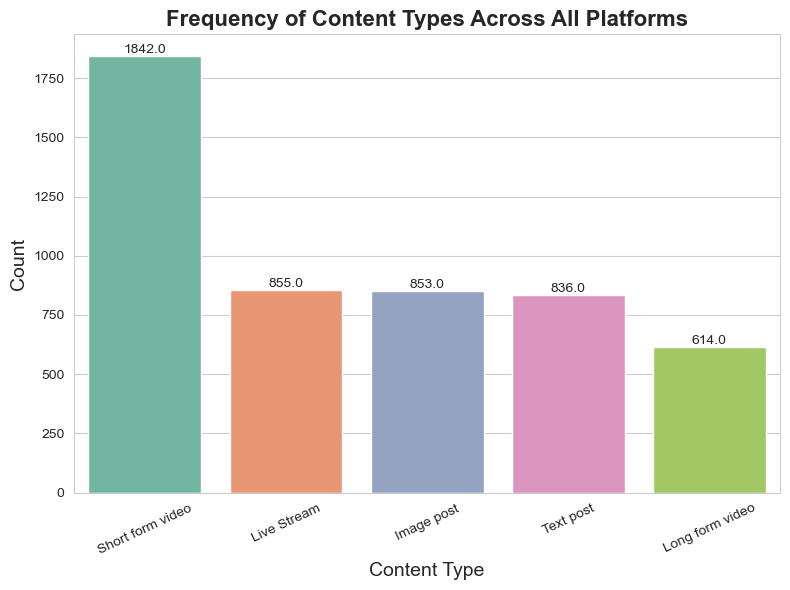

In [44]:
plt.figure(figsize=(8,6))

# Order content types by frequency
order = CONCAT['Content_Type'].value_counts().index

ax = sns.countplot(
    data=CONCAT,
    x='Content_Type',
    order=order,
    palette='Set2'
)

# --- ADD VALUE LABELS ON TOP OF EACH BAR ---
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10
        #fontweight='bold'
    )

plt.title('Frequency of Content Types Across All Platforms', fontsize=16, fontweight='bold')
plt.xlabel('Content Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


#### The interactive nature across social media platforms indicates that short form video as the top content type leading engagement.

In [45]:
month_order = ['JAN','FEB','MAR','APR','MAY','JUN',
               'JUL','AUG','SEP','OCT','NOV','DEC']

# Only keep months that actually appear in your data
present_months = [m for m in month_order if m in CONCAT['Month'].unique()]
present_months

['JAN',
 'FEB',
 'MAR',
 'APR',
 'MAY',
 'JUN',
 'JUL',
 'AUG',
 'SEP',
 'OCT',
 'NOV',
 'DEC']

In [46]:
monthly_eng = (
    CONCAT.groupby('Month', observed=True)['Engagement_Rate']
            .mean()
            .reindex(present_months)
            .reset_index()
)

print(monthly_eng)


   Month  Engagement_Rate
0    JAN               51
1    FEB               31
2    MAR               49
3    APR               40
4    MAY               54
5    JUN               68
6    JUL               50
7    AUG               47
8    SEP              117
9    OCT               50
10   NOV               62
11   DEC               60


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/4223739932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


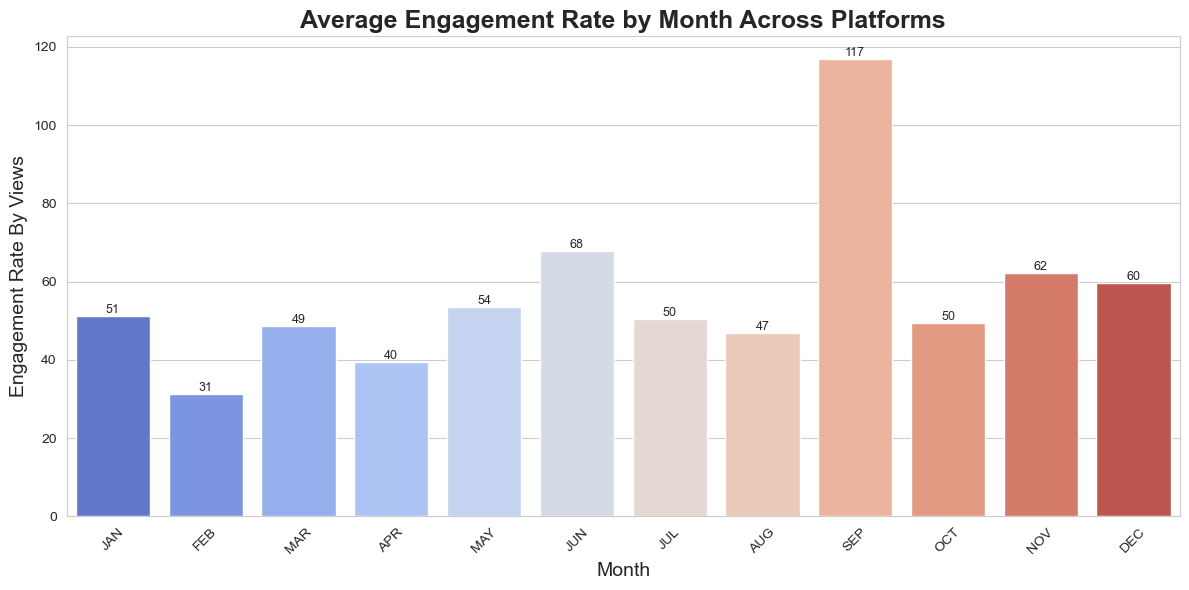

In [47]:
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=monthly_eng,
    x='Month',
    y='Engagement_Rate',
    palette='coolwarm'
)

plt.title('Average Engagement Rate by Month Across Platforms',
          fontsize=18, fontweight='bold')
plt.xlabel('Month', fontsize=14)
plt.ylabel('Engagement Rate By Views', fontsize=14)
plt.xticks(rotation=45)

# Add value labels on each bar
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.0f}',
                (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


#### According to my data, the month of September shows more enegagement levels followed by July and February having the least rate of engagement.

In [48]:
region_eng = (
    CONCAT.groupby('Region', observed=True)['Engagement_Rate']
             .mean()
             .sort_values(ascending=False)
             .reset_index()
)

print(region_eng)


      Region  Engagement_Rate
0        USA               91
1  Australia               56
2      Japan               55
3     Canada               55
4         UK               54
5     Brazil               53
6      India               50
7    Germany               35


/var/folders/s5/xxr506r10qlgjnrpg0_ntbqh0000gn/T/ipykernel_71265/2957306022.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


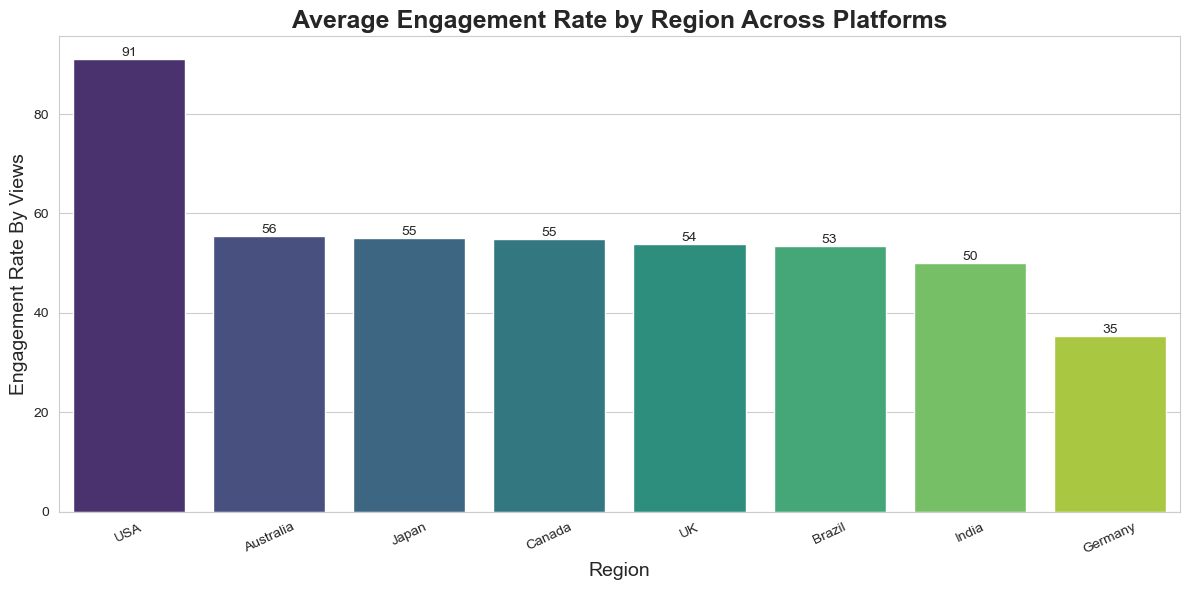

In [49]:
sns.set_style("whitegrid")

plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=region_eng,
    x='Region',
    y='Engagement_Rate',
    palette='viridis'
)

plt.title('Average Engagement Rate by Region Across Platforms',
          fontsize=18, fontweight='bold')
plt.xlabel('Region', fontsize=14)
plt.ylabel('Engagement Rate By Views', fontsize=14)
plt.xticks(rotation=25)

# Add value labels
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.0f}',
                (p.get_x() + p.get_width()/2., h),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


#### According to my data, USA indicates that individuals are actiively engaged across social media platforms and Germany with the least engagement.